# Pré-processamento de Dados e Baseline

In [145]:
# Realizando os imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
import joblib
import os

In [146]:
# Carregando o dataset itub4_raw.csv
df = pd.read_csv("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/database/raw/itub4_raw.csv", index_col="Date", parse_dates=True)

In [147]:
FEATURES = ["Open", "High", "Low", "Close", "Volume", "EMA_60", "log_return_close"]
TARGET = "log_return_close"
WINDOW_SIZE = 50
TRAIN_RATIO = 0.80

### Tratamento de valores ausentes

In [148]:
# Preços ausentes (NaN): interpolação linear preserva a continuidade da série
price_cols = ["Open", "High", "Low", "Close", "EMA_60"]
df[price_cols] = df[price_cols].interpolate(method="linear", limit_direction="both")

# Volume zerado: substituir pelo último valor válido (forward fill)
df["Volume"] = df["Volume"].replace(0, np.nan)
df["Volume"] = df["Volume"].fillna(0)

# Verificação final — não deve sobrar nenhum NaN nas colunas base
assert df.isnull().sum().sum() == 0, "Ainda há valores ausentes após tratamento!"
print("Tratamento de ausentes concluído. Nenhum NaN restante.")

# Retorno logarítmico do Close — nova variável-alvo (ADR 0001)
# r_t = ln(Close_t / Close_{t-1})
df["log_return_close"] = np.log(df["Close"] / df["Close"].shift(1))

# Remove a primeira linha (NaN gerado pela defasagem da diferenciação)
df = df.dropna()

print(f"Dataset após criação do log return: {df.shape}")
print(f"log_return_close — µ: {df['log_return_close'].mean():.6f} | σ: {df['log_return_close'].std():.6f}")

Tratamento de ausentes concluído. Nenhum NaN restante.
Dataset após criação do log return: (1244, 7)
log_return_close — µ: 0.000595 | σ: 0.015841


### Divisão de treino e teste

In [149]:
n = len(df)
train_size = int(n * TRAIN_RATIO)

df_train = df.iloc[:train_size]
df_test  = df.iloc[train_size:]

print(f"Total: {n} dias")
print(f"Treino: {len(df_train)} dias  ({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Teste:  {len(df_test)}  dias  ({df_test.index[0].date()} → {df_test.index[-1].date()})")

Total: 1244 dias
Treino: 995 dias  (2021-05-31 → 2025-05-27)
Teste:  249  dias  (2025-05-28 → 2026-05-26)


### Normalização Z-score por feature

In [150]:
os.makedirs("models/scalers", exist_ok=True)

scalers = {}
df_train_scaled = df_train.copy()
df_test_scaled  = df_test.copy()

for col in FEATURES:
    scaler = StandardScaler()
    # Fit apenas no treino
    df_train_scaled[col] = scaler.fit_transform(df_train[[col]])
    # Transform no teste com os parâmetros do treino
    df_test_scaled[col]  = scaler.transform(df_test[[col]])

    scalers[col] = scaler
    joblib.dump(scaler, f"/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/scalers/scaler_{col.lower()}.pkl")
    print(f"  {col}: µ={scaler.mean_[0]:.4f}, σ={scaler.scale_[0]:.4f}")

print("\nScalers serializados em models/scalers/")

  Open: µ=20.8454, σ=4.3953
  High: µ=21.0723, σ=4.4125
  Low: µ=20.6256, σ=4.3905
  Close: µ=20.8501, σ=4.4096
  Volume: µ=34815025.7799, σ=16727166.2250
  EMA_60: µ=20.5202, σ=3.8895
  log_return_close: µ=0.0006, σ=0.0162

Scalers serializados em models/scalers/


In [151]:
print("=== Treino ===")
print(df_train_scaled.describe().loc[["mean", "std"]].round(4))

print("\n=== Teste ===")
print(df_test_scaled.describe().loc[["mean", "std"]].round(4))

=== Treino ===
       Close    High     Low    Open  Volume  EMA_60  log_return_close
mean -0.0000  0.0000  0.0000 -0.0000 -0.0000 -0.0000            0.0000
std   1.0005  1.0005  1.0005  1.0005  1.0005  1.0005            1.0005

=== Teste ===
       Close    High     Low    Open  Volume  EMA_60  log_return_close
mean  3.8760  3.9090  3.8623  3.8926 -0.6044  4.1138            0.0061
std   1.1072  1.1306  1.0873  1.1161  0.6001  1.1538            0.8961


### Definição de janela temporal

In [152]:
def create_windows(data: pd.DataFrame, window_size: int, target_col: str):
    """
    Retorna X com shape (n_samples, window_size, n_features)
    e y com shape (n_samples,) contendo o valor de fechamento do dia seguinte.
    """
    X, y = [], []
    values = data.values
    target_idx = data.columns.get_loc(target_col)

    for i in range(window_size, len(data)):
        X.append(values[i - window_size : i, :])   # janela de 50 dias
        y.append(values[i, target_idx])             # fechamento do dia seguinte

    return np.array(X), np.array(y)


X_train, y_train = create_windows(df_train_scaled, WINDOW_SIZE, TARGET)
X_test,  y_test  = create_windows(df_test_scaled,  WINDOW_SIZE, TARGET)

print(f"X_train: {X_train.shape}  →  (amostras, janela, features)")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (945, 50, 7)  →  (amostras, janela, features)
y_train: (945,)
X_test:  (199, 50, 7)
y_test:  (199,)


In [153]:
df_processed = pd.concat([df_train_scaled, df_test_scaled])
df_processed.to_csv("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/database/processed/ITUB4_processed.csv", index=True)
print(f"Dataset processado salvo: data/processed/ITUB4_processed.csv ({len(df_processed)} linhas)")

Dataset processado salvo: data/processed/ITUB4_processed.csv (1244 linhas)


## Implementação de Modelo de Persistência ( Baseline )

In [154]:
# Carrega o scaler do retorno logarítmico (fit apenas no treino — sem data leakage)
scaler_log_return = joblib.load("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/scalers/scaler_log_return_close.pkl")

# Desnormaliza y_test: espaço normalizado → retorno logarítmico real
y_test_log = scaler_log_return.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Preços âncora P_t: último Close real de cada janela de teste
# Para a previsão i (i começa em WINDOW_SIZE), a âncora é Close[i-1] no split de teste
anchor_prices = df_test["Close"].values[WINDOW_SIZE - 1 : -1]

# Preço real de fechamento para t+1 em R$ (ground truth)
y_test_real = df_test["Close"].values[WINDOW_SIZE:]

# Baseline de persistência: r̂ = 0 → P̂_{t+1} = P_t * e^0 = P_t
# Equivalente a prever que o preço não muda (modelo de persistência clássico)
y_pred_baseline_real = anchor_prices.copy()

print(f"Âncoras P_t     — min: R${anchor_prices.min():.2f} | max: R${anchor_prices.max():.2f}")
print(f"y_test_real     — min: R${y_test_real.min():.2f} | max: R${y_test_real.max():.2f}")
print(f"Amostras no conjunto de teste: {len(y_test_real)}")

Âncoras P_t     — min: R$32.47 | max: R$48.91
y_test_real     — min: R$32.94 | max: R$48.91
Amostras no conjunto de teste: 199


In [155]:
np.save("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/baseline/y_pred_baseline.npy", y_pred_baseline_real)
np.save("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/baseline/y_test_real.npy",     y_test_real)

print("Arrays serializados em models/baseline/")

Arrays serializados em models/baseline/


### Recuperação do índice temporal do conjunto de teste

In [156]:
n = len(df_processed)
train_size = int(n * TRAIN_RATIO)

# As primeiras WINDOW_SIZE linhas do split de teste são consumidas pela janela
# A primeira previsão corresponde ao índice train_size + WINDOW_SIZE
test_dates = df_processed.index[train_size + WINDOW_SIZE:]

assert len(test_dates) == len(y_test_real), (
    f"Incompatibilidade de tamanhos: datas={len(test_dates)}, y_test={len(y_test_real)}"
)

print(f"Período de teste: {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"Total de pregões no teste: {len(test_dates)}")

np.save("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/test_dates.npy", test_dates.values)
print("test_dates.npy serializado em models/lstm/")

Período de teste: 2025-08-07 → 2026-05-26
Total de pregões no teste: 199
test_dates.npy serializado em models/lstm/


### Gráfico: Preço real vs Baseline

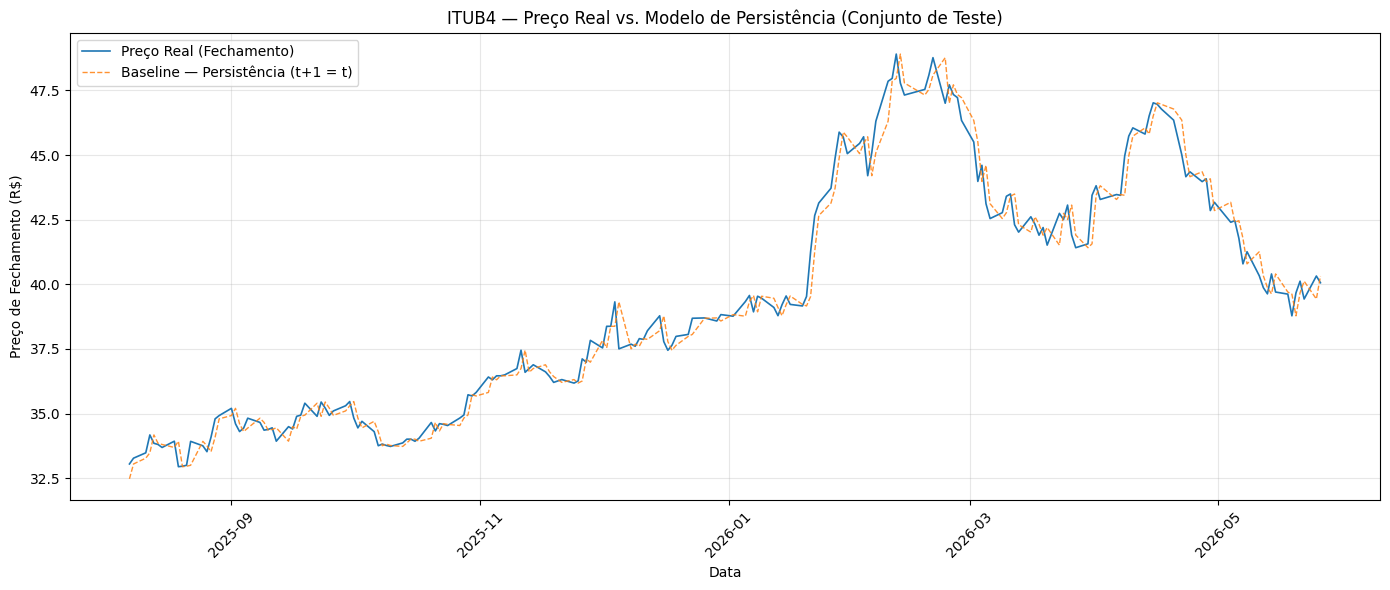

In [157]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, y_test_real,        color="#1f77b4", linewidth=1.2,
        label="Preço Real (Fechamento)")
ax.plot(test_dates, y_pred_baseline_real, color="#ff7f0e", linewidth=1.0,
        linestyle="--", alpha=0.85, label="Baseline — Persistência (t+1 = t)")

ax.set_title("ITUB4 — Preço Real vs. Modelo de Persistência (Conjunto de Teste)")
ax.set_ylabel("Preço de Fechamento (R$)")
ax.set_xlabel("Data")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/06_baseline_vs_real.png", dpi=300, bbox_inches="tight")
plt.show()

## Avaliação de Baseline

### Cálculo de Métricas

In [158]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # Exclui pontos onde y_true == 0 para evitar divisão por zero
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


baseline_rmse = rmse(y_test_real, y_pred_baseline_real)
baseline_mae  = mae(y_test_real,  y_pred_baseline_real)
baseline_mape = mape(y_test_real, y_pred_baseline_real)

print("=== Métricas do Baseline (Persistência) ===")
print(f"  RMSE : R$ {baseline_rmse:.4f}")
print(f"  MAE  : R$ {baseline_mae:.4f}")
print(f"  MAPE :    {baseline_mape:.4f} %")

=== Métricas do Baseline (Persistência) ===
  RMSE : R$ 0.6227
  MAE  : R$ 0.4705
  MAPE :    1.1652 %


### Serialização das métricas

In [159]:
import json

metrics = {
    "model":      "persistence_baseline",
    "split":      "test",
    "n_samples":  int(len(y_test_real)),
    "RMSE":       round(baseline_rmse, 6),
    "MAE":        round(baseline_mae,  6),
    "MAPE":       round(baseline_mape, 6),
}

with open("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/baseline/baseline_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Métricas salvas em models/baseline/baseline_metrics.json")
print(json.dumps(metrics, indent=2))

Métricas salvas em models/baseline/baseline_metrics.json
{
  "model": "persistence_baseline",
  "split": "test",
  "n_samples": 199,
  "RMSE": 0.622651,
  "MAE": 0.470452,
  "MAPE": 1.165213
}


### Gráfico de resíduos de baseline

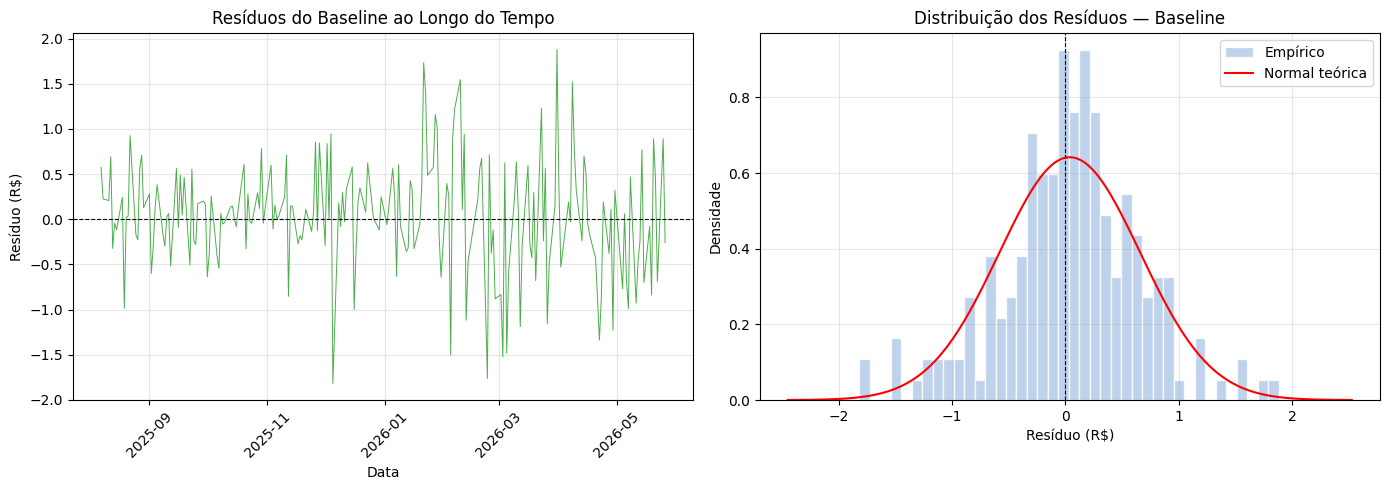

Resíduos — µ: 0.0381 | σ: 0.6215
Curtose: 0.7858


In [160]:
from scipy.stats import norm

residuos = y_test_real - y_pred_baseline_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Série temporal dos resíduos ---
axes[0].plot(test_dates, residuos, color="#2ca02c", linewidth=0.7, alpha=0.85)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Resíduos do Baseline ao Longo do Tempo")
axes[0].set_ylabel("Resíduo (R$)")
axes[0].set_xlabel("Data")
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[0].get_xticklabels(), rotation=45)

# --- Histograma dos resíduos com curva normal ---
mu_res, sigma_res = residuos.mean(), residuos.std()
x_res = np.linspace(mu_res - 4 * sigma_res, mu_res + 4 * sigma_res, 200)

axes[1].hist(residuos, bins=40, density=True,
             color="#aec7e8", edgecolor="white", alpha=0.8, label="Empírico")
axes[1].plot(x_res, norm.pdf(x_res, mu_res, sigma_res),
             "r-", linewidth=1.5, label="Normal teórica")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Distribuição dos Resíduos — Baseline")
axes[1].set_xlabel("Resíduo (R$)")
axes[1].set_ylabel("Densidade")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("data/figures/07_baseline_residuos.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Resíduos — µ: {mu_res:.4f} | σ: {sigma_res:.4f}")
print(f"Curtose: {pd.Series(residuos).kurt():.4f}")

In [161]:
print("\n========================================")
print("  Resumo: Baseline de Persistência")
print("========================================")
print(f"  Período de teste : {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"  Amostras         : {len(y_test_real)}")
print(f"  RMSE             : R$ {baseline_rmse:.4f}")
print(f"  MAE              : R$ {baseline_mae:.4f}")
print(f"  MAPE             : {baseline_mape:.4f} %")
print("========================================\n")
print("Estes valores são o piso mínimo que a LSTM deverá superar na Fase 3.")


  Resumo: Baseline de Persistência
  Período de teste : 2025-08-07 → 2026-05-26
  Amostras         : 199
  RMSE             : R$ 0.6227
  MAE              : R$ 0.4705
  MAPE             : 1.1652 %

Estes valores são o piso mínimo que a LSTM deverá superar na Fase 3.


# Criando modelo LSTM

In [162]:
# Realizando import do TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [163]:
# Criando modelo LSTM
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(WINDOW_SIZE, len(FEATURES))),
    LSTM(150, return_sequences=False),
    Dropout(0.20),
    Dense(1, activation="linear"),
], name="LSTM_ITUB4")

In [164]:
# Compilação do modelo instanciado
model.compile(
    loss="mse",        # Mean Squared Error — função de perda padrão para regressão
    optimizer="adam",  # Adam com lr=0.001 (padrão Keras)
    metrics=["mae"],   # MAE exibido durante o treino para monitoramento visual
)

model.summary()

Model: "LSTM_ITUB4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 150)            │        94,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,951 (370.90 KB)

 Trainable params: 94,951 (370.90 KB)

 Non-trainable params: 0 (0.00 B)

In [165]:
# Verifica se o modelo aceita o shape esperado sem erros
# Usa inferência eager (sem compilação de grafo) para evitar overhead na primeira chamada
dummy_input = np.zeros((1, WINDOW_SIZE, len(FEATURES)), dtype=np.float32)
dummy_output = model(dummy_input, training=False).numpy()

assert dummy_output.shape == (1, 1), (
    f"Shape de saída inesperado: {dummy_output.shape}"
)
print(f"Verificação de shape: OK — saída com shape {dummy_output.shape}")
print(f"Total de parâmetros treináveis: {model.count_params():,}")

Verificação de shape: OK — saída com shape (1, 1)
Total de parâmetros treináveis: 94,951


In [166]:
# Definição de Hiperparâmetros

EPOCHS      = 150    # teto; Early Stopping interromperá antes se convergir
# Teto suficientemente alto para que o Early Stopping atue antes do limite; com paciência 10, o treinamento máximo real é de ~60–90 épocas em séries desta escala.
BATCH_SIZE  = 32     # padrão amplamente utilizado em séries temporais com LSTM
# Lotes menores produzem gradientes mais ruidosos mas tendem a generalizar melhor; 32 é o valor padrão em estudos semelhante
VAL_SPLIT   = 0.10   # 10% do treino reservado para validação interna
# A validação é extraída das últimas 10% amostras do treino (Keras preserva a ordem cronológica ao usar)

In [167]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configuração de callbacks

early_stop = EarlyStopping(
    monitor="val_loss",      # métrica monitorada: perda no conjunto de validação
    patience=10,             # encerra após 10 épocas sem melhora
    restore_best_weights=True,  # restaura automaticamente os pesos da melhor época
    verbose=1,
)

checkpoint = ModelCheckpoint(
    filepath="/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_itub4.keras",
    monitor="val_loss",
    save_best_only=True,     # salva apenas quando val_loss melhora
    verbose=1,
)

In [168]:
# Execução do treinamento

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop, checkpoint],
    shuffle=False,   # preserva a ordem temporal — NÃO embaralhar séries temporais
    verbose=1,
)

best_epoch = np.argmin(history.history["val_loss"]) + 1
print(f"\nMelhor época: {best_epoch}")
print(f"val_loss mínimo : {min(history.history['val_loss']):.6f}")
print(f"train_loss correspondente: {history.history['loss'][best_epoch - 1]:.6f}")

Epoch 1/150
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6586 - mae: 0.8769
Epoch 1: val_loss improved from None to 0.89726, saving model to /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_itub4.keras

Epoch 1: finished saving model to /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_itub4.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0901 - mae: 0.7473 - val_loss: 0.8973 - val_mae: 0.7114
Epoch 2/150
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5957 - mae: 0.8617
Epoch 2: val_loss improved from 0.89726 to 0.67844, saving model to /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_itub4.keras

Epoch 2: finished saving model to /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_itub4.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0632 - mae: 0.7470 - val_loss: 0.6784 - val_mae: 0.6004
Epoch 3/150
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1

In [169]:
from tensorflow.keras.models import load_model

# Importando melhor modelo gerado durante o treinamento

model = load_model("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_itub4.keras")

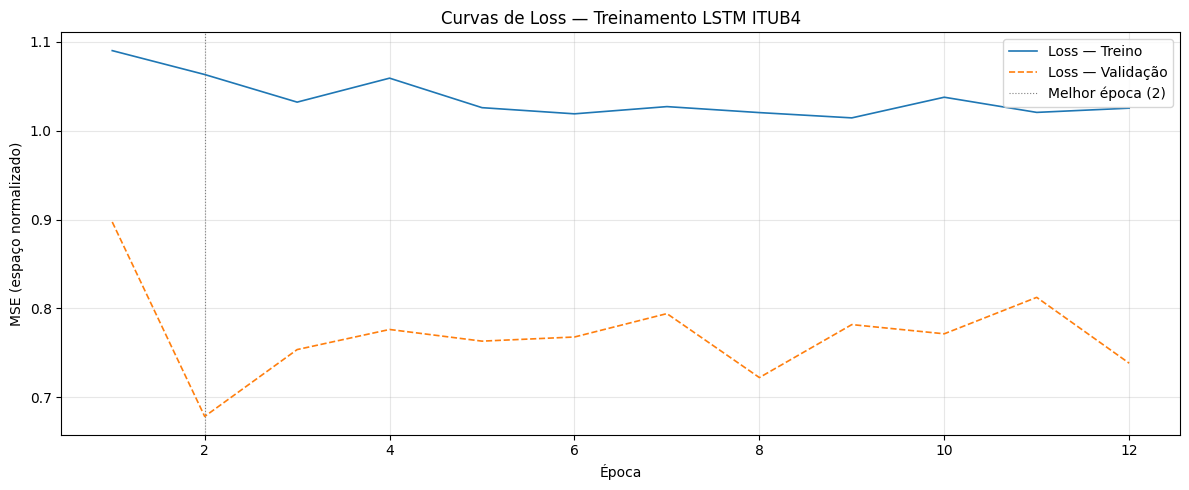

In [170]:
# Plotando curvas de loss

epochs_range = range(1, len(history.history["loss"]) + 1)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(epochs_range, history.history["loss"],
        color="#1f77b4", linewidth=1.2, label="Loss — Treino")
ax.plot(epochs_range, history.history["val_loss"],
        color="#ff7f0e", linewidth=1.2, linestyle="--", label="Loss — Validação")

ax.axvline(best_epoch, color="gray", linewidth=0.8, linestyle=":",
           label=f"Melhor época ({best_epoch})")

ax.set_title("Curvas de Loss — Treinamento LSTM ITUB4")
ax.set_xlabel("Época")
ax.set_ylabel("MSE (espaço normalizado)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("data/figures/08_history_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [171]:
n_epochs_executadas = len(history.history["loss"])

print("\n========================================")
print("  Resumo do Treinamento LSTM")
print("========================================")
print(f"  Épocas executadas    : {n_epochs_executadas} / {EPOCHS}")
print(f"  Melhor época         : {best_epoch}")
print(f"  train_loss (melhor)  : {history.history['loss'][best_epoch - 1]:.6f}")
print(f"  val_loss   (melhor)  : {min(history.history['val_loss']):.6f}")
print(f"  Modelo salvo em      : /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_itub4.keras")
print("========================================\n")


  Resumo do Treinamento LSTM
  Épocas executadas    : 12 / 150
  Melhor época         : 2
  train_loss (melhor)  : 1.063172
  val_loss   (melhor)  : 0.678440
  Modelo salvo em      : /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_itub4.keras



## Avaliação comparativa LSTM vs Baseline

### Geração de previsões de preço mínimo e máximo no conjunto de teste

In [172]:
# Geração das previsões em espaço normalizado
y_pred_lstm_norm = model.predict(X_test, batch_size=32, verbose=0).flatten()

# Desnormaliza: normalizado → retorno logarítmico real
scaler_log_return = joblib.load("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/scalers/scaler_log_return_close.pkl")
y_pred_lstm_log = scaler_log_return.inverse_transform(
    y_pred_lstm_norm.reshape(-1, 1)
).flatten()

# Reconstrói preço em R$: P̂_{t+1} = P_t * e^(r̂_{t+1})  (ADR 0001, seção 2)
anchor_prices = df_test["Close"].values[WINDOW_SIZE - 1 : -1]
y_pred_lstm_real = anchor_prices * np.exp(y_pred_lstm_log)

# Ground truth em R$
y_test_real = df_test["Close"].values[WINDOW_SIZE:]

print(f"Previsões LSTM — min: R${y_pred_lstm_real.min():.2f} | max: R${y_pred_lstm_real.max():.2f}")
print(f"Valores reais  — min: R${y_test_real.min():.2f}       | max: R${y_test_real.max():.2f}")
print(f"Amostras no teste: {len(y_test_real)}")

assert y_pred_lstm_real.shape == y_test_real.shape, (
    f"Shape incompatível: pred={y_pred_lstm_real.shape}, real={y_test_real.shape}"
)

Previsões LSTM — min: R$32.58 | max: R$49.06
Valores reais  — min: R$32.94       | max: R$48.91
Amostras no teste: 199


### Cálculo das métricas da LSTM

In [173]:
lstm_rmse = rmse(y_test_real, y_pred_lstm_real)
lstm_mae  = mae(y_test_real,  y_pred_lstm_real)
lstm_mape = mape(y_test_real, y_pred_lstm_real)

print("=== Métricas da LSTM ===")
print(f"  RMSE : R$ {lstm_rmse:.4f}")
print(f"  MAE  : R$ {lstm_mae:.4f}")
print(f"  MAPE :    {lstm_mape:.4f} %")

=== Métricas da LSTM ===
  RMSE : R$ 0.6293
  MAE  : R$ 0.4719
  MAPE :    1.1703 %


### Tabela Comparativa - Baseline vs LSTM

In [174]:
with open("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/baseline/baseline_metrics.json") as f:
    baseline_metrics = json.load(f)

baseline_rmse = baseline_metrics["RMSE"]
baseline_mae  = baseline_metrics["MAE"]
baseline_mape = baseline_metrics["MAPE"]

# Melhoria relativa da LSTM sobre o baseline (%)
melhoria_rmse = (baseline_rmse - lstm_rmse) / baseline_rmse * 100
melhoria_mae  = (baseline_mae  - lstm_mae)  / baseline_mae  * 100
melhoria_mape = (baseline_mape - lstm_mape) / baseline_mape * 100

print("\n========================================")
print("  Comparativo LSTM vs. Baseline")
print("========================================")
print(f"  {'Métrica':<8} {'Baseline':>12} {'LSTM':>12} {'Melhoria':>10}")
print(f"  {'-'*46}")
print(f"  {'RMSE':<8} R$ {baseline_rmse:>9.4f} R$ {lstm_rmse:>9.4f} {melhoria_rmse:>+9.2f}%")
print(f"  {'MAE':<8} R$ {baseline_mae:>9.4f} R$ {lstm_mae:>9.4f}  {melhoria_mae:>+9.2f}%")
print(f"  {'MAPE':<8}    {baseline_mape:>9.4f}%    {lstm_mape:>9.4f}% {melhoria_mape:>+9.2f}%")
print("========================================")


  Comparativo LSTM vs. Baseline
  Métrica      Baseline         LSTM   Melhoria
  ----------------------------------------------
  RMSE     R$    0.6227 R$    0.6293     -1.06%
  MAE      R$    0.4705 R$    0.4719      -0.30%
  MAPE           1.1652%       1.1703%     -0.44%


In [175]:
os.makedirs("models/lstm", exist_ok=True)

lstm_metrics_dict = {
    "model":              "lstm_single_layer",
    "architecture":       "Input(50,6) → LSTM(150) → Dropout(0.2) → Dense(1)",
    "split":              "test",
    "n_samples":          int(len(y_test_real)),
    "best_epoch":         int(best_epoch),
    "RMSE":               round(lstm_rmse,  6),
    "MAE":                round(lstm_mae,   6),
    "MAPE":               round(lstm_mape,  6),
    "melhoria_vs_baseline": {
        "RMSE_pct": round(melhoria_rmse, 4),
        "MAE_pct":  round(melhoria_mae,  4),
        "MAPE_pct": round(melhoria_mape, 4),
    },
}

with open("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_metrics.json", "w") as f:
    json.dump(lstm_metrics_dict, f, indent=2)

print("Métricas salvas em /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_metrics.json")
print(json.dumps(lstm_metrics_dict, indent=2))

Métricas salvas em /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/lstm_metrics.json
{
  "model": "lstm_single_layer",
  "architecture": "Input(50,6) \u2192 LSTM(150) \u2192 Dropout(0.2) \u2192 Dense(1)",
  "split": "test",
  "n_samples": 199,
  "best_epoch": 2,
  "RMSE": 0.62927,
  "MAE": 0.471878,
  "MAPE": 1.170343,
  "melhoria_vs_baseline": {
    "RMSE_pct": -1.0631,
    "MAE_pct": -0.3031,
    "MAPE_pct": -0.4402
  }
}


In [176]:
np.save("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/y_pred_lstm.npy", y_pred_lstm_real)
print("Previsões salvas em /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/y_pred_lstm.npy")

Previsões salvas em /Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/lstm/y_pred_lstm.npy


## Gráfico 1 — Preço real vs. LSTM

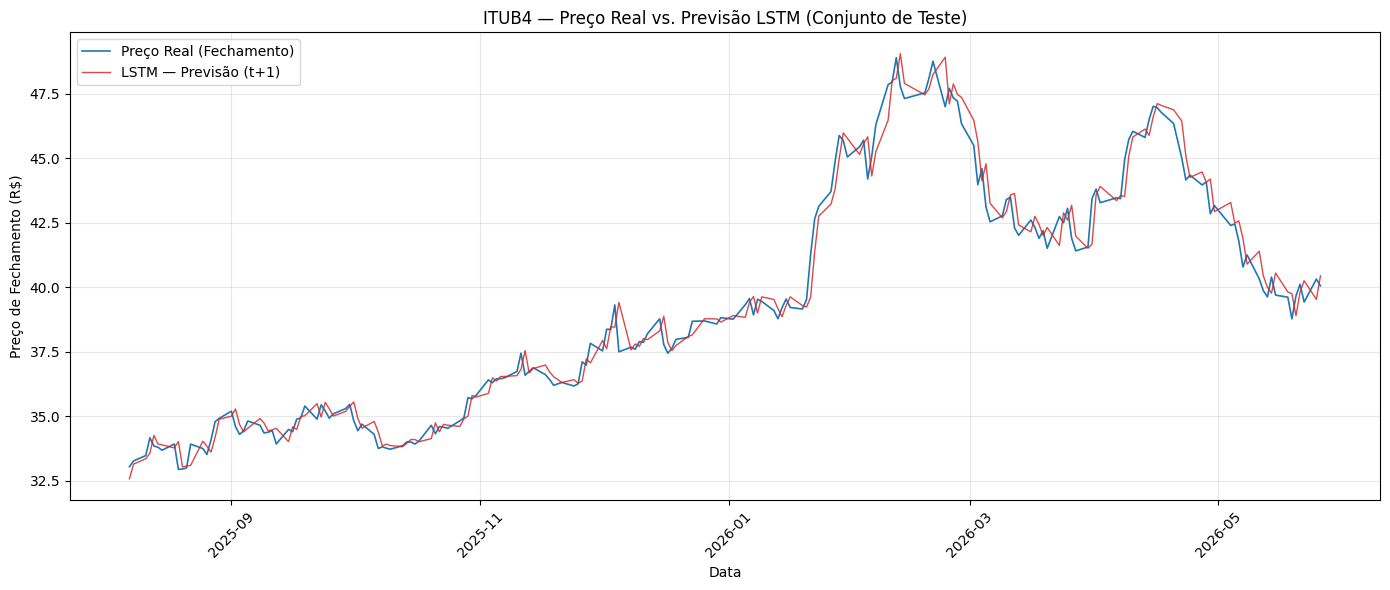

In [177]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, y_test_real,       color="#1f77b4", linewidth=1.2,
        label="Preço Real (Fechamento)")
ax.plot(test_dates, y_pred_lstm_real,  color="#d62728", linewidth=1.0,
        linestyle="-", alpha=0.85, label="LSTM — Previsão (t+1)")

ax.set_title("ITUB4 — Preço Real vs. Previsão LSTM (Conjunto de Teste)")
ax.set_ylabel("Preço de Fechamento (R$)")
ax.set_xlabel("Data")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/09_lstm_vs_real.png", dpi=300, bbox_inches="tight")
plt.show()

## Gráfico 2 — LSTM vs. Baseline vs. Real

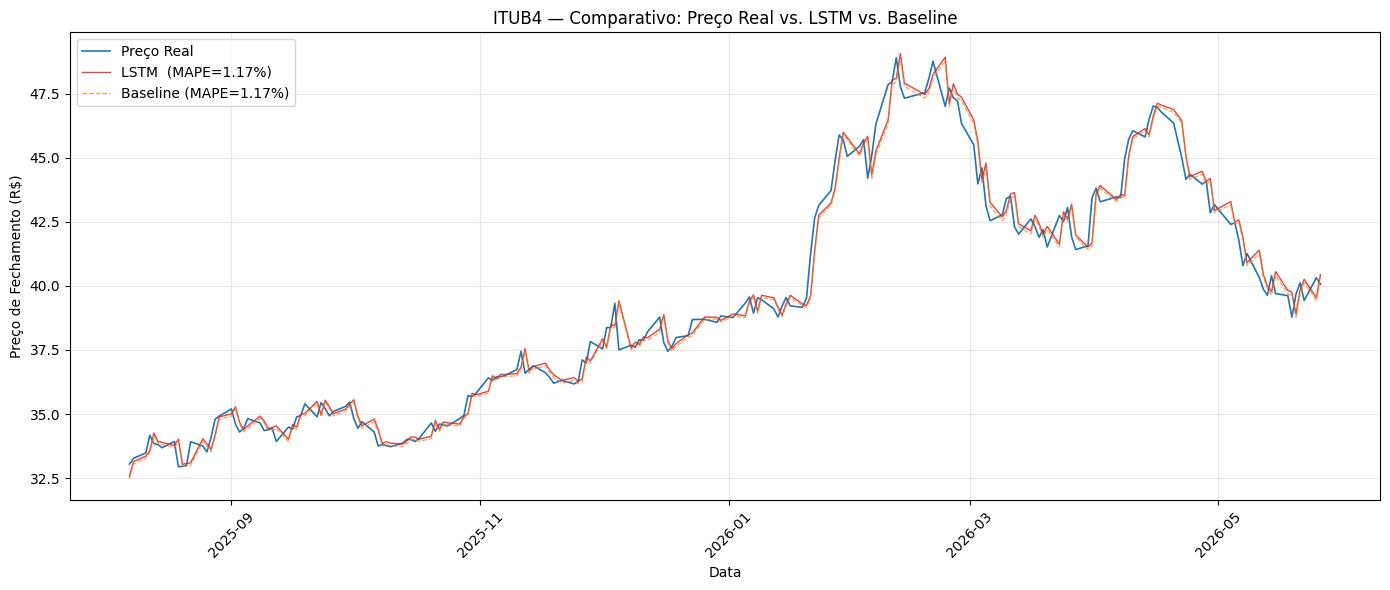

In [178]:
np.load("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/baseline/y_pred_baseline.npy")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, y_test_real,            color="#1f77b4", linewidth=1.2,
        label="Preço Real")
ax.plot(test_dates, y_pred_lstm_real,       color="#d62728", linewidth=1.0,
        alpha=0.85, label=f"LSTM  (MAPE={lstm_mape:.2f}%)")
ax.plot(test_dates, y_pred_baseline_real,   color="#ff7f0e", linewidth=0.9,
        linestyle="--", alpha=0.75, label=f"Baseline (MAPE={baseline_mape:.2f}%)")

ax.set_title("ITUB4 — Comparativo: Preço Real vs. LSTM vs. Baseline")
ax.set_ylabel("Preço de Fechamento (R$)")
ax.set_xlabel("Data")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/10_lstm_vs_baseline.png", dpi=300, bbox_inches="tight")
plt.show()
#print("Gráfico salvo em data/figures/10_lstm_vs_baseline.png")

## Gráfico 03 - Resíduos da LSTM

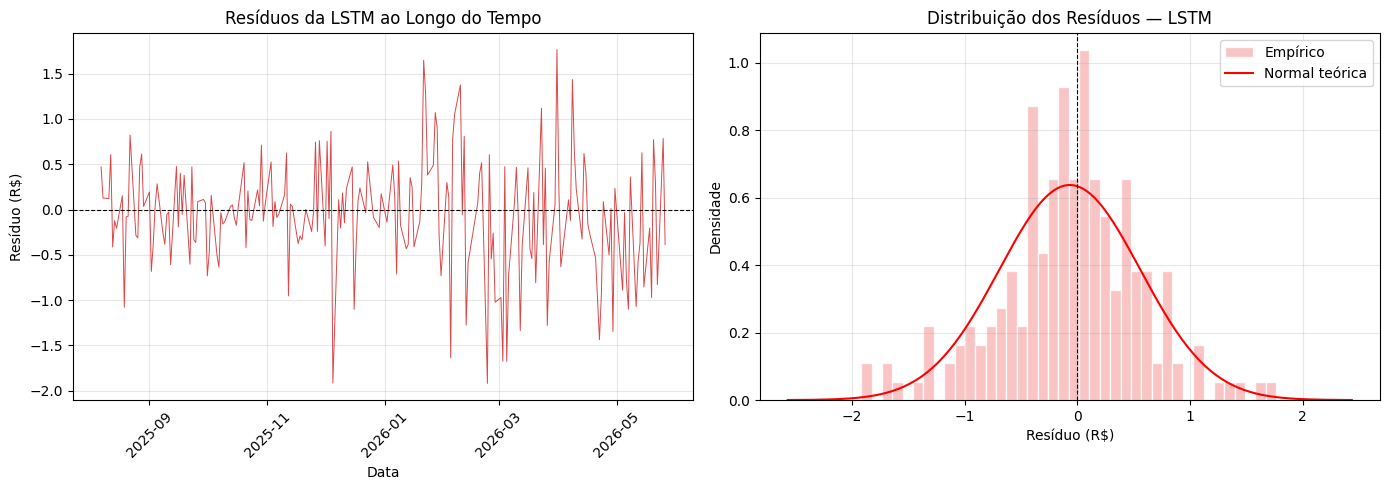

Resíduos LSTM — µ: -0.0666 | σ: 0.6257
Curtose: 0.8127


In [179]:
from scipy.stats import norm

residuos_lstm = y_test_real - y_pred_lstm_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Série temporal dos resíduos ---
axes[0].plot(test_dates, residuos_lstm, color="#d62728", linewidth=0.7, alpha=0.85)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Resíduos da LSTM ao Longo do Tempo")
axes[0].set_ylabel("Resíduo (R$)")
axes[0].set_xlabel("Data")
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[0].get_xticklabels(), rotation=45)

# --- Histograma com curva normal ---
mu_res    = residuos_lstm.mean()
sigma_res = residuos_lstm.std()
x_res     = np.linspace(mu_res - 4 * sigma_res, mu_res + 4 * sigma_res, 200)

axes[1].hist(residuos_lstm, bins=40, density=True,
             color="#f7b6b6", edgecolor="white", alpha=0.8, label="Empírico")
axes[1].plot(x_res, norm.pdf(x_res, mu_res, sigma_res),
             "r-", linewidth=1.5, label="Normal teórica")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Distribuição dos Resíduos — LSTM")
axes[1].set_xlabel("Resíduo (R$)")
axes[1].set_ylabel("Densidade")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("data/figures/11_lstm_residuos.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Resíduos LSTM — µ: {mu_res:.4f} | σ: {sigma_res:.4f}")
print(f"Curtose: {pd.Series(residuos_lstm).kurt():.4f}")
#print("Gráfico salvo em data/figures/11_lstm_residuos.png")

In [180]:
print("\n========================================")
print("  Resumo — Fase 3: Treinamento da LSTM")
print("========================================")
print(f"  Período de teste : {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"  Amostras         : {len(y_test_real)}")
print(f"  Melhor época     : {best_epoch}")
print("")
print(f"  {'Métrica':<8} {'Baseline':>12} {'LSTM':>12} {'Δ':>10}")
print(f"  {'-'*46}")
print(f"  {'RMSE':<8} R$ {baseline_rmse:>9.4f} R$ {lstm_rmse:>9.4f} {melhoria_rmse:>+9.2f}%")
print(f"  {'MAE':<8} R$ {baseline_mae:>9.4f} R$ {lstm_mae:>9.4f}  {melhoria_mae:>+9.2f}%")
print(f"  {'MAPE':<8}    {baseline_mape:>9.4f}%    {lstm_mape:>9.4f}% {melhoria_mape:>+9.2f}%")
print("========================================\n")


  Resumo — Fase 3: Treinamento da LSTM
  Período de teste : 2025-08-07 → 2026-05-26
  Amostras         : 199
  Melhor época     : 2

  Métrica      Baseline         LSTM          Δ
  ----------------------------------------------
  RMSE     R$    0.6227 R$    0.6293     -1.06%
  MAE      R$    0.4705 R$    0.4719      -0.30%
  MAPE           1.1652%       1.1703%     -0.44%

